## Imports

In [8]:
%load_ext autoreload
%autoreload 2

from ageing_packages.SR_models import SR_sim, SR_plotting
from ageing_packages.utils import sr_utils as utils
from ageing_packages.hetero_analysis import correlation_analysis as ca
from ageing_packages.hetero_analysis import twin_analysis as ta
from ageing_packages.hetero_analysis import survival_analysis as sa
from ageing_packages.hetero_analysis import hetero_plotting as hp
from ageing_packages.mortality_data_analysis import HMD
from ageing_packages.mortality_models.gamma_gompertz import GammaGompertz as gg
from ageing_packages.hetero_analysis import nhanes_analysis as nhanes

import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.colors as mcolors
import pickle

def remove_top_right_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()            
    ax.get_yaxis().tick_left()
# Apply this to all future plots
plt.rc('axes', facecolor='white')
plt.rc('axes.spines', top=False, right=False)
plt.rc('axes', grid=False)

# Make tick sizes and labels 1.5 times bigger
plt.rc('xtick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('ytick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('xtick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('ytick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('xtick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('ytick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('xtick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger
plt.rc('ytick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger

# === Ensures vector elements for PDF output ===
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42  # Ensures TrueType fonts, which stay as text
mpl.rcParams['ps.fonttype'] = 42   # Ensures TrueType fonts for PS as well
mpl.rcParams['svg.fonttype'] = 'none'  # Use system fonts in SVG, keep elements editable

# This helps ensure that paths, shapes, and lines are saved as actual vectors.
# To maximize editability, avoid raster/bitmap elements in figures.
# When saving, use:
# plt.savefig('figure.pdf', format='pdf', dpi=300)  # dpi has effect only for raster, not vector elements.
# If you use raster images (e.g., imshow, pcolormesh), consider vector alternatives or set rasterized=True only for those artists.

# Configure plotly defaults
pio.templates.default = "plotly_white"
pio.templates["plotly_white"].layout.update(
    paper_bgcolor='white',
    plot_bgcolor='white',
    xaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    ),
    yaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    )
)

import pingouin as pg
import pandas as pd
from scipy import interpolate
from scipy.stats import gaussian_kde, gennorm, norm, gamma, beta
import seaborn as sns
import matplotlib.cm as cm
import sys, os, importlib, warnings, pickle
from scipy.stats import pearsonr
from lifelines import KaplanMeierFitter
import thresholds_functions as th

import matplotlib.path as mpath
import matplotlib.patches as mpatches

def curly_arrow(start, end, arr_size = 1, n = 5, col='gray', linew=1., width = 0.1, ax=None):
    # NOTE: Added ax as argument to avoid NameError
    xmin, ymin = start
    xmax, ymax = end
    dist = np.sqrt((xmin - xmax)**2 + (ymin - ymax)**2)
    n0 = dist / (2 * np.pi)
    
    x = np.linspace(0, dist, 151) + xmin
    y = width * np.sin(n * x / n0) + ymin
    line = plt.Line2D(x, y, color=col, lw=linew)
    
    del_x = xmax - xmin
    del_y = ymax - ymin
    ang = np.arctan2(del_y, del_x)
    
    if ax is None:
        ax = plt.gca()
    line.set_transform(mpl.transforms.Affine2D().rotate_around(xmin, ymin, ang) + ax.transData)
    ax.add_line(line)

    verts = np.array([[0,1],[0,-1],[2,0],[0,1]]).astype(float) * arr_size
    verts[:,1] += ymax
    verts[:,0] += xmax
    path = mpath.Path(verts)
    patch = mpatches.PathPatch(path, fc=col, ec=col)

    patch.set_transform(mpl.transforms.Affine2D().rotate_around(xmax, ymax, ang) + ax.transData)
    return patch


Loaded exposure group results from /Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/notebooks/thresholds, noise/saved_results/exposure_groups_results.pkl
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Fig 4 - Historical

In [9]:
sweden_cohort = HMD(country = 'swe', gender = 'both', data_type = 'cohort')
sweden_period = HMD(country = 'swe', gender = 'both', data_type = 'period')

denmark_period = HMD(country = 'dan', gender = 'both', data_type = 'period')
denmark_cohort = HMD(country = 'dan', gender = 'both', data_type = 'cohort')

usa_period = HMD(country = 'usa', gender = 'both', data_type = 'period')

/Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/ageing_packages/mortality_data_analysis/HMD_lifetables.py:1221: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(log_hazard_model, ages_fit, np.log(hazards_fit), p0=p0, absolute_sigma=False)


0.7718435758969873 0.5739620184319452


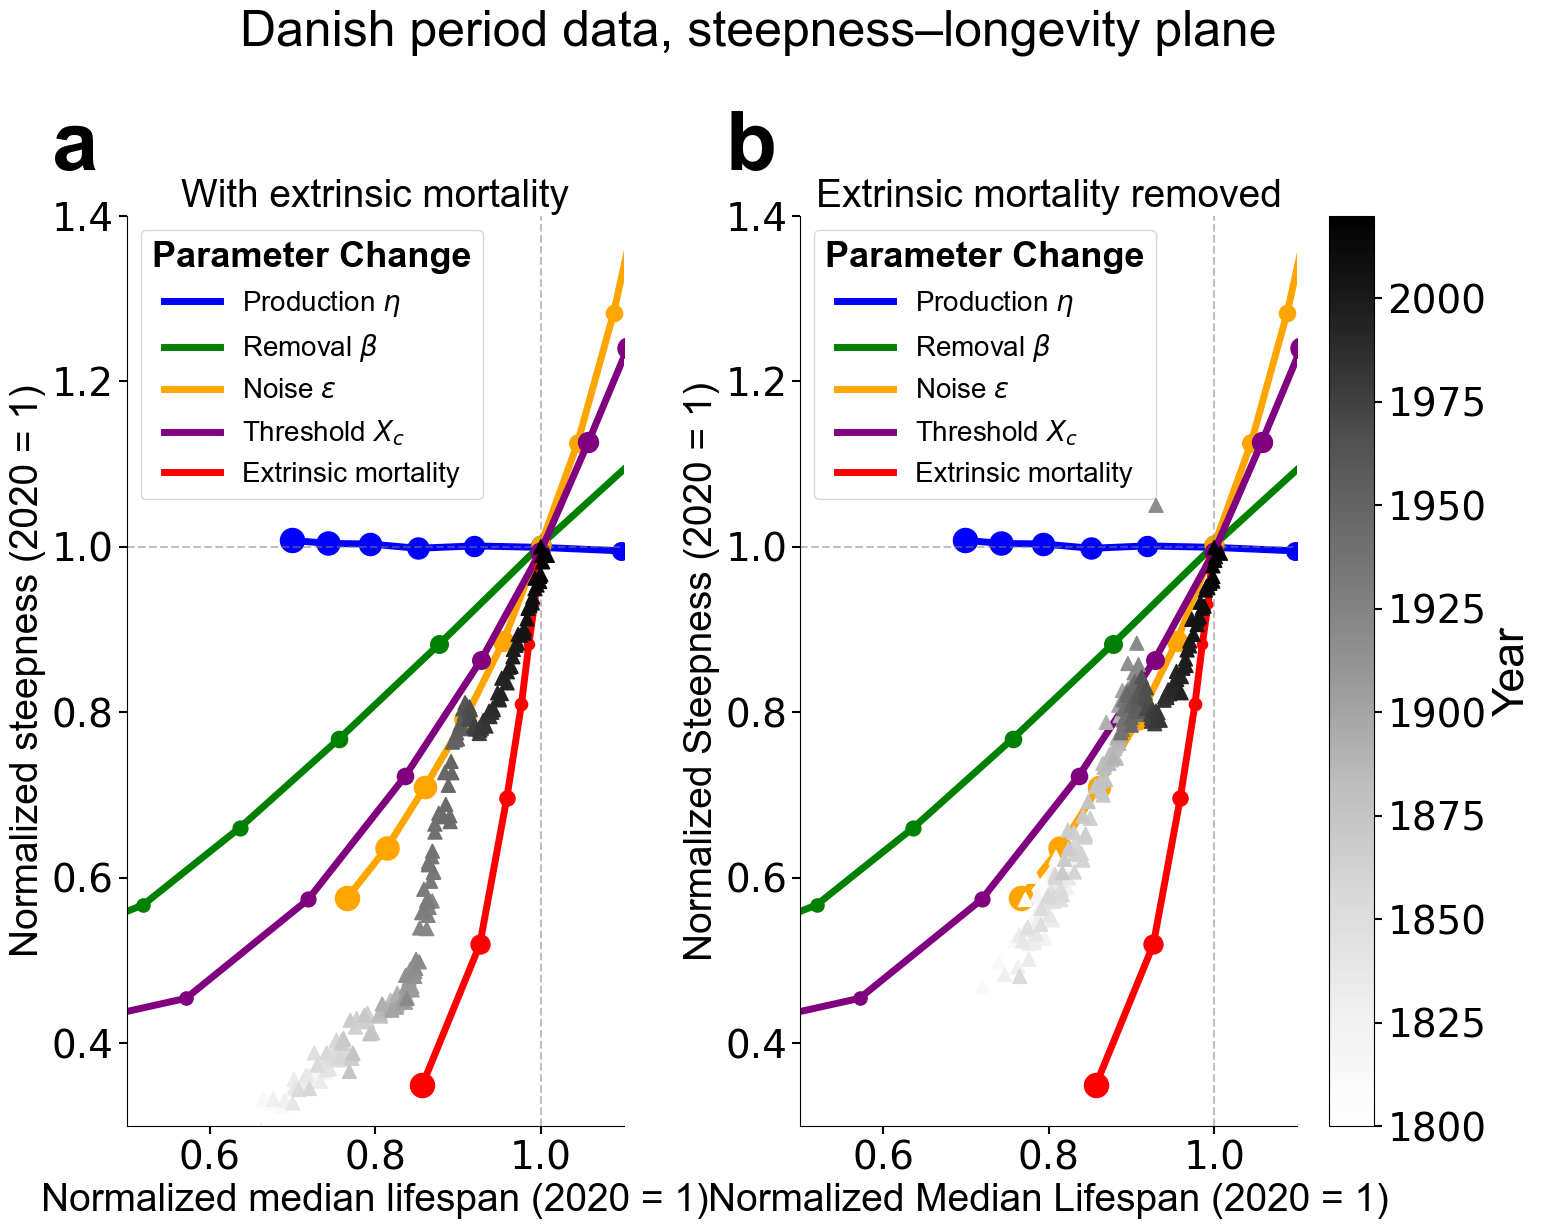

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ----- GLOBAL PLOTTING PARAMS -----
TICK_SIZE = 28
LEGEND_SIZE = 16
LABEL_SIZE = 28
TITLE_SIZE = 36
SUBPLOT_TITLE_SIZE = 28
SUBPLOT_LABEL_SIZE = 60
COLORBAR_LABEL_SIZE = 32

# ----- parameters -----
year_start, year_end = 1800, 2020
years       = np.arange(year_start, year_end + 1, 1)
ref_year    = year_end
age_start   = 20
hmd         = sweden_period        # <- your HMD dataframe / object
cmap        = 'Greys'

# ----- figure & axes -----
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 12))

# ========== left panel : with extrinsic mortality ==========
th.plot_steepness_longevity(param_type='variation',
                            from_t=age_start,
                            h_ext=True,
                            ax=ax1,
                            marker_size_range=(20, 300), 
                            linewidth = 5)

th.plot_historical_changes(hmd, years,
                           ax=ax1,
                           without_extrinsic=False,
                           ref_year=ref_year,
                           from_t=age_start,
                           cmap=cmap,
                           show_colorbar = False)

ax1.set_xlim(0.5, 1.1)
ax1.set_ylim(0.3, 1.4)
ax1.set_title('With extrinsic mortality', fontsize=SUBPLOT_TITLE_SIZE, fontfamily='Arial')
ax1.tick_params(labelsize=TICK_SIZE)
ax1.grid(False)
if ax1.get_legend_handles_labels()[0]:
    ax1.legend(fontsize=LEGEND_SIZE)

# ========== right panel : without extrinsic mortality ==========
th.plot_steepness_longevity(param_type='variation',
                            from_t=age_start,
                            h_ext=True,
                            ax=ax2,
                            marker_size_range=(20, 300),
                            linewidth = 5)

th.plot_historical_changes(hmd, years,
                           ax=ax2,
                           without_extrinsic=True,
                           ref_year=ref_year,
                           from_t=age_start,
                           cmap=cmap,
                           show_colorbar = True)

ax2.set_xlim(0.5, 1.1)
ax2.set_ylim(0.3, 1.4)
ax2.set_title('Extrinsic mortality removed', fontsize=SUBPLOT_TITLE_SIZE, fontfamily='Arial')
ax2.tick_params(labelsize=TICK_SIZE)
ax2.grid(False)
if ax2.get_legend_handles_labels()[0]:
    ax2.legend(fontsize=LEGEND_SIZE)

# ----- colour-bar formatting (find every colour-bar axis) -----
for cax in [a for a in fig.axes if a.get_label() == '<colorbar>']:
    cax.tick_params(labelsize=TICK_SIZE)
    cax.set_ylabel('Year', fontsize=COLORBAR_LABEL_SIZE, fontfamily='Arial')

# ----- axis-label fonts -----
for ax in (ax1, ax2):
    ax.xaxis.label.set_fontsize(LABEL_SIZE)
    ax.xaxis.label.set_fontfamily('Arial')
    ax.yaxis.label.set_fontsize(LABEL_SIZE)
    ax.yaxis.label.set_fontfamily('Arial')

# ----- global title & subplot labels -----
fig.suptitle('Danish period data, steepness–longevity plane',
             fontsize=TITLE_SIZE, y=1.02, fontfamily='Arial')
ax1.text(-0.15, 1.05, 'a', transform=ax1.transAxes,
         fontsize=SUBPLOT_LABEL_SIZE, fontweight='bold', fontfamily='Arial')
ax2.text(-0.15, 1.05, 'b', transform=ax2.transAxes,
         fontsize=SUBPLOT_LABEL_SIZE, fontweight='bold', fontfamily='Arial')

plt.tight_layout()

# ----- save -----
#plt.savefig('Figures/Fig4AB.pdf', bbox_inches='tight', dpi=300)
#plt.savefig('Figures/Fig4AB.svg', bbox_inches='tight', dpi=300)
#plt.savefig('Figures/Fig4AB.pdf', bbox_inches='tight', dpi=300)

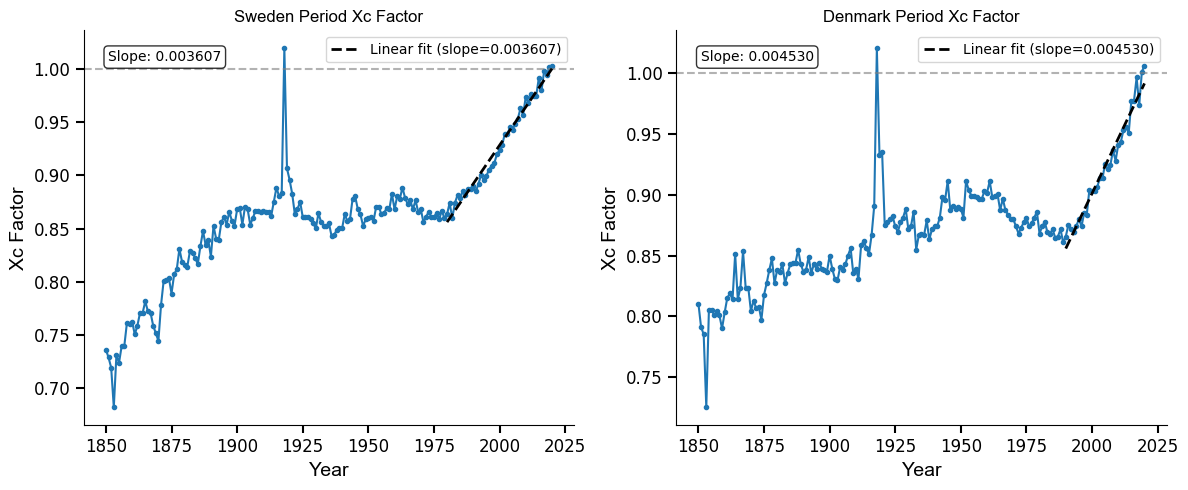

In [11]:
# ----- Map each Sweden and Denmark period year to its closest Xc factor -----
years_xc = np.arange(1850, 2021, 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Sweden
xc_map_swe, xc_years_swe, xc_factors_swe = th.map_xc_factor_to_years(
    sweden_period, years_xc, ref_year=2020, from_t=20, ax=ax1
)
ax1.set_title('Sweden Period Xc Factor')

# Fit linear regression for Sweden (1880-2020)
mask_swe = (xc_years_swe >= 1980) & (xc_years_swe <= 2020)
years_fit_swe = xc_years_swe[mask_swe]
xc_fit_swe = xc_factors_swe[mask_swe]
slope_swe, intercept_swe = np.polyfit(years_fit_swe, xc_fit_swe, 1)
fit_line_swe = slope_swe * years_fit_swe + intercept_swe
ax1.plot(years_fit_swe, fit_line_swe, 'k--', linewidth=2, label=f'Linear fit (slope={slope_swe:.6f})')
ax1.text(0.05, 0.95, f'Slope: {slope_swe:.6f}', transform=ax1.transAxes, 
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax1.legend()

# Denmark
xc_map_den, xc_years_den, xc_factors_den = th.map_xc_factor_to_years(
    denmark_period, years_xc, ref_year=2020, from_t=20, ax=ax2
)
ax2.set_title('Denmark Period Xc Factor')

# Fit linear regression for Denmark (1880-2020)
mask_den = (xc_years_den >= 1990) & (xc_years_den <= 2020)
years_fit_den = xc_years_den[mask_den]
xc_fit_den = xc_factors_den[mask_den]
slope_den, intercept_den = np.polyfit(years_fit_den, xc_fit_den, 1)
fit_line_den = slope_den * years_fit_den + intercept_den
ax2.plot(years_fit_den, fit_line_den, 'k--', linewidth=2, label=f'Linear fit (slope={slope_den:.6f})')
ax2.text(0.05, 0.95, f'Slope: {slope_den:.6f}', transform=ax2.transAxes, 
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax2.legend()

plt.tight_layout()

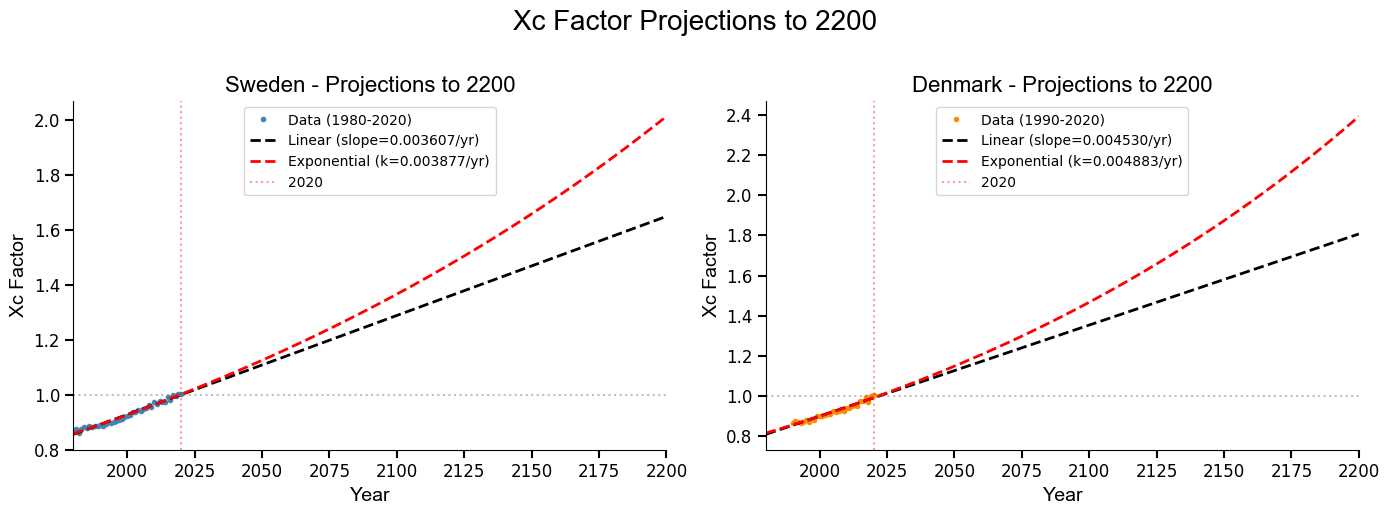


--- Sweden ---
  Year 2020: Linear Xc = 1.0004, Exponential Xc = 1.0020
  Year 2050: Linear Xc = 1.1086, Exponential Xc = 1.1256
  Year 2080: Linear Xc = 1.2168, Exponential Xc = 1.2645
  Year 2100: Linear Xc = 1.2889, Exponential Xc = 1.3664
  Year 2150: Linear Xc = 1.4693, Exponential Xc = 1.6588
  Year 2200: Linear Xc = 1.6496, Exponential Xc = 2.0136

--- Denmark ---
  Year 2020: Linear Xc = 0.9918, Exponential Xc = 0.9931
  Year 2050: Linear Xc = 1.1277, Exponential Xc = 1.1497
  Year 2080: Linear Xc = 1.2636, Exponential Xc = 1.3311
  Year 2100: Linear Xc = 1.3542, Exponential Xc = 1.4676
  Year 2150: Linear Xc = 1.5807, Exponential Xc = 1.8735
  Year 2200: Linear Xc = 1.8072, Exponential Xc = 2.3915


In [12]:
# ----- Project Xc factor to 2200: Linear vs Exponential scenarios -----
years_proj = np.arange(1980, 2201, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ===================== SWEDEN =====================
# Existing data for Sweden (1980-2020)
mask_swe = (xc_years_swe >= 1980) & (xc_years_swe <= 2020)
years_data_swe = xc_years_swe[mask_swe]
xc_data_swe = xc_factors_swe[mask_swe]

# Linear fit
slope_swe, intercept_swe = np.polyfit(years_data_swe, xc_data_swe, 1)

# Exponential fit: Xc(t) = A * exp(k * t)
# Fit in log space: ln(Xc) = ln(A) + k*t
log_xc_swe = np.log(xc_data_swe)
k_swe, log_A_swe = np.polyfit(years_data_swe, log_xc_swe, 1)
A_swe = np.exp(log_A_swe)

# --- Left: Sweden Linear & Exponential ---
ax = axes[0]
ax.plot(years_data_swe, xc_data_swe, 'o', color='steelblue', markersize=3, label='Data (1980-2020)')
xc_linear_swe = slope_swe * years_proj + intercept_swe
ax.plot(years_proj, xc_linear_swe, 'k--', linewidth=2, label=f'Linear (slope={slope_swe:.6f}/yr)')
xc_exp_swe = A_swe * np.exp(k_swe * years_proj)
ax.plot(years_proj, xc_exp_swe, 'r--', linewidth=2, label=f'Exponential (k={k_swe:.6f}/yr)')
ax.axhline(y=1, linestyle=':', color='gray', alpha=0.5)
ax.axvline(x=2020, linestyle=':', color='red', alpha=0.4, label='2020')
ax.set_xlabel('Year', fontsize=14, fontfamily='Arial')
ax.set_ylabel('Xc Factor', fontsize=14, fontfamily='Arial')
ax.set_title('Sweden - Projections to 2200', fontsize=16, fontfamily='Arial')
ax.legend(fontsize=10)
ax.tick_params(labelsize=12)
ax.set_xlim(1980, 2200)

# ===================== DENMARK =====================
# Existing data for Denmark (1990-2020)
mask_den = (xc_years_den >= 1990) & (xc_years_den <= 2020)
years_data_den = xc_years_den[mask_den]
xc_data_den = xc_factors_den[mask_den]

# Linear fit
slope_den, intercept_den = np.polyfit(years_data_den, xc_data_den, 1)

# Exponential fit
log_xc_den = np.log(xc_data_den)
k_den, log_A_den = np.polyfit(years_data_den, log_xc_den, 1)
A_den = np.exp(log_A_den)

# --- Right: Denmark Linear & Exponential ---
ax = axes[1]
ax.plot(years_data_den, xc_data_den, 'o', color='darkorange', markersize=3, label='Data (1990-2020)')
xc_linear_den = slope_den * years_proj + intercept_den
ax.plot(years_proj, xc_linear_den, 'k--', linewidth=2, label=f'Linear (slope={slope_den:.6f}/yr)')
xc_exp_den = A_den * np.exp(k_den * years_proj)
ax.plot(years_proj, xc_exp_den, 'r--', linewidth=2, label=f'Exponential (k={k_den:.6f}/yr)')
ax.axhline(y=1, linestyle=':', color='gray', alpha=0.5)
ax.axvline(x=2020, linestyle=':', color='red', alpha=0.4, label='2020')
ax.set_xlabel('Year', fontsize=14, fontfamily='Arial')
ax.set_ylabel('Xc Factor', fontsize=14, fontfamily='Arial')
ax.set_title('Denmark - Projections to 2200', fontsize=16, fontfamily='Arial')
ax.legend(fontsize=10)
ax.tick_params(labelsize=12)
ax.set_xlim(1980, 2200)

fig.suptitle('Xc Factor Projections to 2200', fontsize=20, fontfamily='Arial', y=1.02)
plt.tight_layout()
plt.show()

# Print projected values at key years
for label, years_d, slope, intercept, A, k in [
    ('Sweden', years_data_swe, slope_swe, intercept_swe, A_swe, k_swe),
    ('Denmark', years_data_den, slope_den, intercept_den, A_den, k_den),
]:
    print(f"\n--- {label} ---")
    for y in [2020, 2050, 2080, 2100, 2150, 2200]:
        xc_lin = slope * y + intercept
        xc_exp = A * np.exp(k * y)
        print(f"  Year {y}: Linear Xc = {xc_lin:.4f}, Exponential Xc = {xc_exp:.4f}")

In [13]:
# ----- Run SR model with projected Xc factors, plot median & max lifespan vs year -----
import time

# Adjusted baseline params (same as run_parameter_study / Figure 4AB)
# karin_params: eta=0.00135*365, beta=0.15*365, kappa=0.5, epsilon=0.142*365, Xc=17
# Then adjusted: Xc*=1.08, eta*=1.26, beta*=1.17
base_dict = utils.load_baseline_human_params_dict()
base_dict['Xc']   = 1.08 * base_dict['Xc']    # 17 * 1.08 = 18.36
base_dict['eta']  = 1.26 * base_dict['eta']    # 0.4928 * 1.26 ≈ 0.6209
base_dict['beta'] = 1.17 * base_dict['beta']   # 54.75 * 1.17 ≈ 64.06

n_sim = int(3e5)
from_t = 20
proj_years = np.arange(1980, 2201, 10)

def run_projections(label, proj_years, xc_linear_func, xc_exp_func, base_dict, n_sim, from_t):
    """Run SR sims for linear and exponential Xc projections."""
    results = {'linear': {'years': [], 'median': [], 'max': []},
               'exponential': {'years': [], 'median': [], 'max': []}}
    
    total = len(proj_years) * 2
    count = 0
    t0 = time.time()
    
    for scenario, xc_func in [('linear', xc_linear_func), ('exponential', xc_exp_func)]:
        for year in proj_years:
            count += 1
            xc_factor = xc_func(year)
            
            # Build param dict with shifted Xc
            param_dict = base_dict.copy()
            for key in param_dict:
                val = param_dict[key]
                if isinstance(val, (np.ndarray, list)) and len(val) == 1:
                    param_dict[key] = np.repeat(val, n_sim)
                elif np.isscalar(val):
                    param_dict[key] = np.repeat(np.array([val]), n_sim)
            param_dict['Xc'] = xc_factor * param_dict['Xc']
            
            sim = utils.create_sr_simulation(params_dict=param_dict, n=n_sim, parallel=True, tmax=200)
            
            median_lifespan = sim.find_time_at_survival(0.5, from_t=from_t, relative=False)
            max_lifespan    = sim.find_time_at_survival(1e-4, from_t=from_t, relative=False)
            
            results[scenario]['years'].append(year)
            results[scenario]['median'].append(median_lifespan)
            results[scenario]['max'].append(max_lifespan)
            
            elapsed = time.time() - t0
            eta_sec = (elapsed / count) * (total - count)
            print(f"  [{label}] {count}/{total} | {scenario} year={year}, "
                  f"Xc_factor={xc_factor:.4f}, median={median_lifespan:.1f}, max={max_lifespan:.1f} "
                  f"({elapsed:.0f}s elapsed, ~{eta_sec:.0f}s remaining)")
    
    for scenario in results:
        for key in results[scenario]:
            results[scenario][key] = np.array(results[scenario][key])
    return results

# Xc projection functions (from previous cell's fits)
xc_linear_func_swe = lambda y: slope_swe * y + intercept_swe
xc_exp_func_swe    = lambda y: A_swe * np.exp(k_swe * y)
xc_linear_func_den = lambda y: slope_den * y + intercept_den
xc_exp_func_den    = lambda y: A_den * np.exp(k_den * y)

print("=== Sweden ===")
results_swe = run_projections('SWE', proj_years, xc_linear_func_swe, xc_exp_func_swe, base_dict, n_sim, from_t)

print("\n=== Denmark ===")
results_den = run_projections('DEN', proj_years, xc_linear_func_den, xc_exp_func_den, base_dict, n_sim, from_t)



=== Sweden ===
  [SWE] 1/46 | linear year=1980, Xc_factor=0.8561, median=76.3, max=101.6 (8s elapsed, ~359s remaining)
  [SWE] 2/46 | linear year=1990, Xc_factor=0.8922, median=78.4, max=103.1 (15s elapsed, ~326s remaining)
  [SWE] 3/46 | linear year=2000, Xc_factor=0.9282, median=80.3, max=104.6 (22s elapsed, ~316s remaining)
  [SWE] 4/46 | linear year=2010, Xc_factor=0.9643, median=81.9, max=105.8 (30s elapsed, ~314s remaining)
  [SWE] 5/46 | linear year=2020, Xc_factor=1.0004, median=83.5, max=107.4 (38s elapsed, ~313s remaining)
  [SWE] 6/46 | linear year=2030, Xc_factor=1.0364, median=85.0, max=107.7 (46s elapsed, ~307s remaining)
  [SWE] 7/46 | linear year=2040, Xc_factor=1.0725, median=86.3, max=109.4 (54s elapsed, ~303s remaining)
  [SWE] 8/46 | linear year=2050, Xc_factor=1.1086, median=87.6, max=109.6 (63s elapsed, ~298s remaining)
  [SWE] 9/46 | linear year=2060, Xc_factor=1.1446, median=88.7, max=111.0 (72s elapsed, ~294s remaining)
  [SWE] 10/46 | linear year=2070, Xc_fact

In [19]:
import pickle

# Save both results_swe and results_den to a pkl for reuse
with open("../../saved_results/cache/simulations/extrapolations_results.pkl", "wb") as f:
    pickle.dump({'results_swe': results_swe, 'results_den': results_den}, f)

print("Saved results to extrapolations_results.pkl")

Saved results to extrapolations_results.pkl


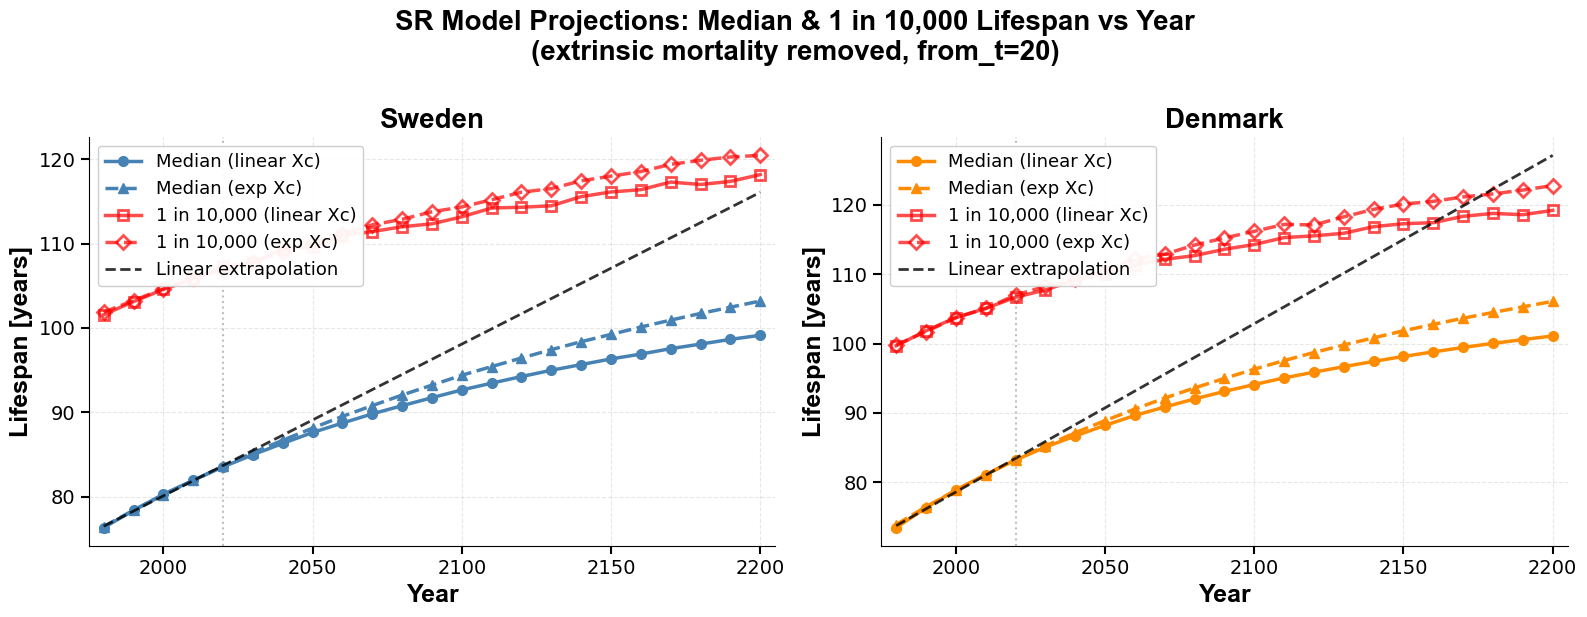

In [14]:
# ----- Plot: 1x2 grid, median + max on same axes -----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, results, data_color in [
    (ax1, 'Sweden', results_swe, 'steelblue'),
    (ax2, 'Denmark', results_den, 'darkorange'),
]:
    # Linear scenario - Median
    ax.plot(results['linear']['years'], results['linear']['median'],
            'o-', color=data_color, linewidth=2.5, markersize=7, label='Median (linear Xc)')
    
    # Exponential scenario - Median
    ax.plot(results['exponential']['years'], results['exponential']['median'],
            '^--', color=data_color, linewidth=2.5, markersize=7, label='Median (exp Xc)')
    
    # Linear scenario - Max (1 in 10,000)
    ax.plot(results['linear']['years'], results['linear']['max'],
            's-', color='red', linewidth=2.5, markersize=7, alpha=0.7,
            markerfacecolor='none', markeredgewidth=2, label='1 in 10,000 (linear Xc)')
    
    # Exponential scenario - Max (1 in 10,000)
    ax.plot(results['exponential']['years'], results['exponential']['max'],
            'D--', color='red', linewidth=2.5, markersize=7, alpha=0.7,
            markerfacecolor='none', markeredgewidth=2, label='1 in 10,000 (exp Xc)')
    
    # Linear fit to median lifespan (1980-2020)
    years_linear = results['linear']['years']
    median_linear = results['linear']['median']
    mask_fit = (years_linear >= 1980) & (years_linear <= 2020)
    years_fit = years_linear[mask_fit]
    median_fit = median_linear[mask_fit]
    
    # Perform linear fit
    coeffs = np.polyfit(years_fit, median_fit, 1)
    slope_fit = coeffs[0]
    intercept_fit = coeffs[1]
    
    # Extrapolate from 1980 onwards (dashed line)
    years_extrap = years_linear[years_linear >= 1980]
    if len(years_extrap) > 0:
        median_extrap = slope_fit * years_extrap + intercept_fit
        ax.plot(years_extrap, median_extrap, '--', color='black', linewidth=2, alpha=0.8, label='Linear extrapolation')
    
    ax.axvline(x=2020, linestyle=':', color='gray', alpha=0.5, linewidth=1.5)
    ax.set_xlabel('Year', fontsize=18, fontfamily='Arial', fontweight='bold')
    ax.set_ylabel('Lifespan [years]', fontsize=18, fontfamily='Arial', fontweight='bold')
    ax.set_title(f'{label}', fontsize=20, fontfamily='Arial', fontweight='bold')
    ax.legend(fontsize=13, loc='upper left', framealpha=0.95)
    ax.tick_params(labelsize=14)
    ax.set_xlim(1975, 2205)
    ax.grid(True, alpha=0.3, linestyle='--')

fig.suptitle('SR Model Projections: Median & 1 in 10,000 Lifespan vs Year\n(extrinsic mortality removed, from_t=20)',
             fontsize=20, fontfamily='Arial', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

  [1/20] Xc_factor=1.00, median=83.5, max=107.4 (4s elapsed, ~78s remaining)
  [2/20] Xc_factor=1.23, median=91.1, max=112.9 (9s elapsed, ~79s remaining)
  [3/20] Xc_factor=1.51, median=97.0, max=116.8 (13s elapsed, ~76s remaining)
  [4/20] Xc_factor=1.85, median=101.6, max=120.0 (18s elapsed, ~72s remaining)
  [5/20] Xc_factor=2.28, median=105.4, max=122.5 (22s elapsed, ~67s remaining)
  [6/20] Xc_factor=2.80, median=108.4, max=125.3 (28s elapsed, ~66s remaining)
  [7/20] Xc_factor=3.44, median=111.1, max=126.3 (33s elapsed, ~62s remaining)
  [8/20] Xc_factor=4.23, median=113.5, max=128.1 (39s elapsed, ~58s remaining)
  [9/20] Xc_factor=5.19, median=116.0, max=130.2 (43s elapsed, ~53s remaining)
  [10/20] Xc_factor=6.38, median=118.4, max=131.3 (48s elapsed, ~48s remaining)
  [11/20] Xc_factor=7.84, median=121.0, max=133.6 (53s elapsed, ~43s remaining)
  [12/20] Xc_factor=9.63, median=123.7, max=135.6 (58s elapsed, ~39s remaining)
  [13/20] Xc_factor=11.83, median=126.7, max=138.2 (63

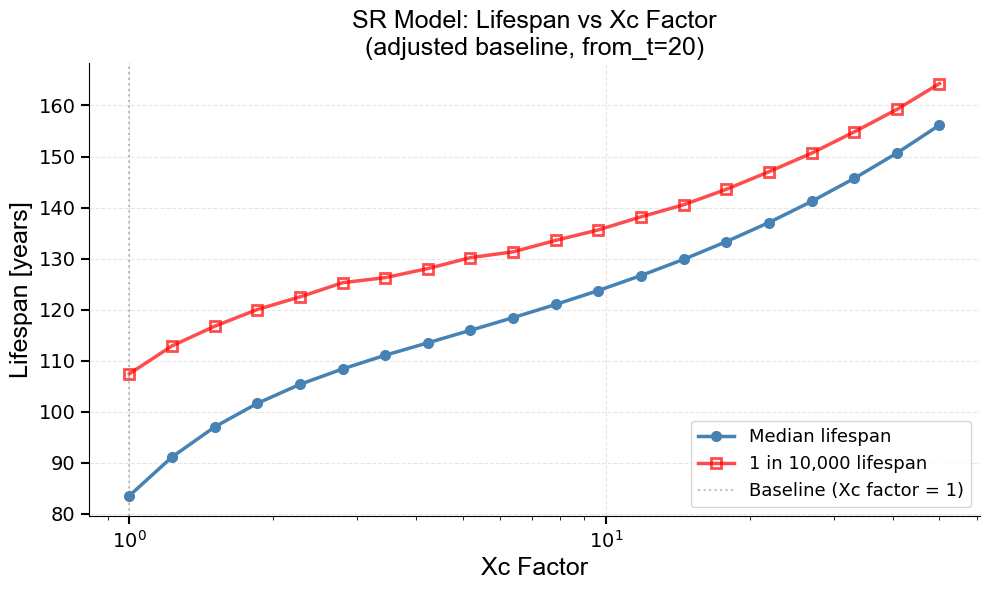

In [18]:
# ----- Map: Xc factor -> median lifespan via SR simulations -----
import time

# Same adjusted baseline as Figure 4AB
base_dict = utils.load_baseline_human_params_dict()
base_dict['Xc']   = 1.08 * base_dict['Xc']
base_dict['eta']  = 1.26 * base_dict['eta']
base_dict['beta'] = 1.17 * base_dict['beta']

n_sim = int(1e5)
from_t = 20

# 20 log-spaced Xc factors from 1 to 50
xc_factors_scan = np.logspace(np.log10(1), np.log10(50), 20)

median_vs_xc = []
max_vs_xc = []

t0 = time.time()
for i, xc_factor in enumerate(xc_factors_scan):
    # Build param dict
    param_dict = base_dict.copy()
    for key in param_dict:
        val = param_dict[key]
        if isinstance(val, (np.ndarray, list)) and len(val) == 1:
            param_dict[key] = np.repeat(val, n_sim)
        elif np.isscalar(val):
            param_dict[key] = np.repeat(np.array([val]), n_sim)
    param_dict['Xc'] = xc_factor * param_dict['Xc']
    
    sim = utils.create_sr_simulation(params_dict=param_dict, n=n_sim, parallel=True, tmax=500)
    
    median_lifespan = sim.find_time_at_survival(0.5, from_t=from_t, relative=False)
    max_lifespan    = sim.find_time_at_survival(1e-4, from_t=from_t, relative=False)
    
    median_vs_xc.append(median_lifespan)
    max_vs_xc.append(max_lifespan)
    
    elapsed = time.time() - t0
    eta_sec = (elapsed / (i + 1)) * (len(xc_factors_scan) - i - 1)
    print(f"  [{i+1}/{len(xc_factors_scan)}] Xc_factor={xc_factor:.2f}, "
          f"median={median_lifespan:.1f}, max={max_lifespan:.1f} "
          f"({elapsed:.0f}s elapsed, ~{eta_sec:.0f}s remaining)")

median_vs_xc = np.array(median_vs_xc)
max_vs_xc = np.array(max_vs_xc)

# ----- Plot -----
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(xc_factors_scan, median_vs_xc, 'o-', color='steelblue', linewidth=2.5, markersize=7, label='Median lifespan')
ax.plot(xc_factors_scan, max_vs_xc, 's-', color='red', linewidth=2.5, markersize=7, 
        markerfacecolor='none', markeredgewidth=2, alpha=0.7, label='1 in 10,000 lifespan')

ax.axvline(x=1, linestyle=':', color='gray', alpha=0.5, linewidth=1.5, label='Baseline (Xc factor = 1)')
ax.set_xlabel('Xc Factor', fontsize=18, fontfamily='Arial')
ax.set_ylabel('Lifespan [years]', fontsize=18, fontfamily='Arial')
ax.set_title('SR Model: Lifespan vs Xc Factor\n(adjusted baseline, from_t=20)', fontsize=18, fontfamily='Arial')
ax.set_xscale('log')
ax.legend(fontsize=13)
ax.tick_params(labelsize=14)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

Sweden - Linear Xc slope: 0.003607/yr, Exponential Xc k: 0.003877/yr
Denmark - Linear Xc slope: 0.004530/yr, Exponential Xc k: 0.004883/yr


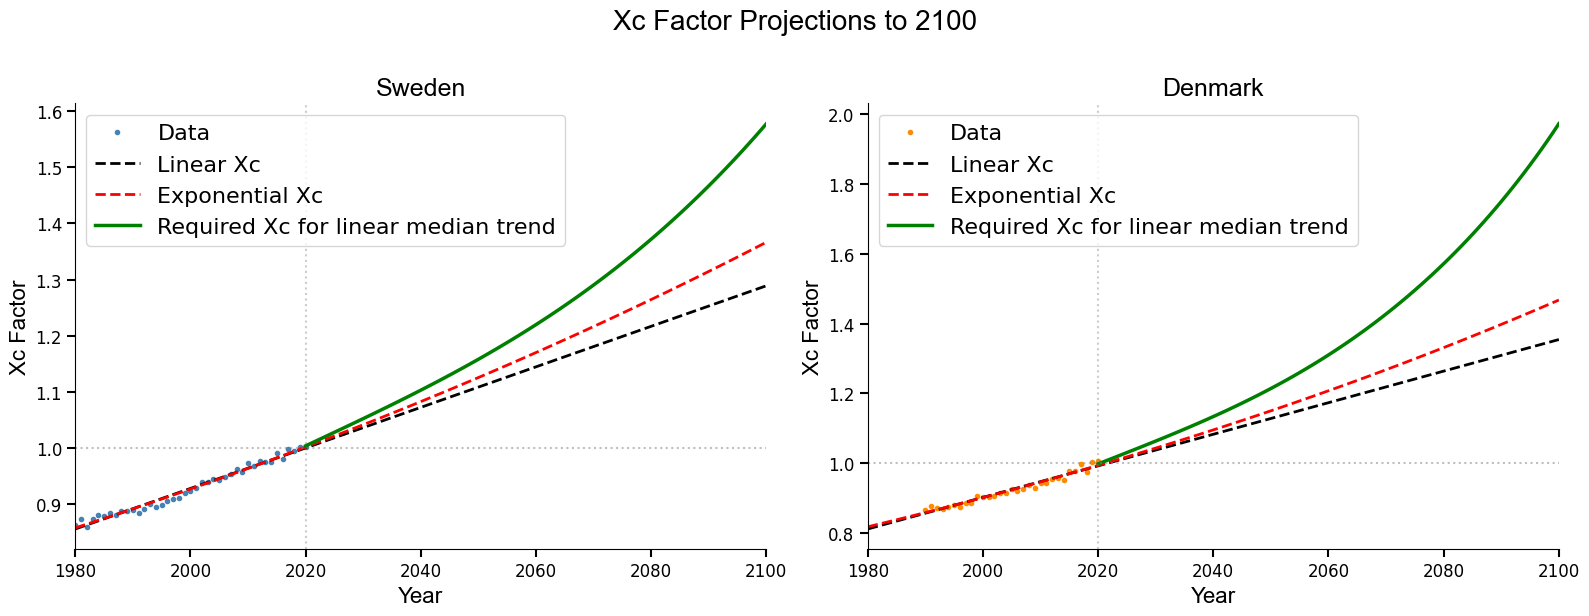


--- Sweden ---
  Year 2020: Linear Xc=1.0004, Exp Xc=1.0020, Required Xc=1.0040
  Year 2050: Linear Xc=1.1086, Exp Xc=1.1256, Required Xc=1.1581
  Year 2080: Linear Xc=1.2168, Exp Xc=1.2645, Required Xc=1.3718
  Year 2100: Linear Xc=1.2889, Exp Xc=1.3664, Required Xc=1.5773

--- Denmark ---
  Year 2020: Linear Xc=0.9918, Exp Xc=0.9931, Required Xc=0.9974
  Year 2050: Linear Xc=1.1277, Exp Xc=1.1497, Required Xc=1.2138
  Year 2080: Linear Xc=1.2636, Exp Xc=1.3311, Required Xc=1.5718
  Year 2100: Linear Xc=1.3542, Exp Xc=1.4676, Required Xc=1.9735


In [28]:
# ----- Project Xc factor to 2100: Linear vs Exponential + Required Xc from linear median trend -----
from scipy.interpolate import interp1d

years_proj = np.arange(1980, 2101, 1)

# === Invert the median-vs-Xc scan to get: target median -> required Xc factor ===
# Use the scan results (xc_factors_scan, median_vs_xc) from the previous cell
# Filter out Nones / NaNs
valid = np.array([m is not None and np.isfinite(m) for m in median_vs_xc])
xc_scan_valid = xc_factors_scan[valid]
median_scan_valid = median_vs_xc[valid]

# Build inverse interpolation: median lifespan -> Xc factor
# Need to sort by median (x-axis for interp1d must be increasing)
sort_idx = np.argsort(median_scan_valid)
median_to_xc = interp1d(median_scan_valid[sort_idx], xc_scan_valid[sort_idx],
                        kind='cubic', fill_value='extrapolate')

# === Get the linear median trend for Sweden (from the results_swe projections) ===
years_lin_swe = results_swe['linear']['years']
median_lin_swe = results_swe['linear']['median']
mask_fit_swe = (years_lin_swe >= 1980) & (years_lin_swe <= 2020)
slope_med_swe, intercept_med_swe = np.polyfit(years_lin_swe[mask_fit_swe], median_lin_swe[mask_fit_swe], 1)

# === Get the linear median trend for Denmark ===
years_lin_den = results_den['linear']['years']
median_lin_den = results_den['linear']['median']
mask_fit_den = (years_lin_den >= 1980) & (years_lin_den <= 2020)
slope_med_den, intercept_med_den = np.polyfit(years_lin_den[mask_fit_den], median_lin_den[mask_fit_den], 1)

# For each projected year, compute the target median from linear extrapolation,
# then look up the required Xc factor
target_median_swe = slope_med_swe * years_proj + intercept_med_swe
required_xc_swe = median_to_xc(target_median_swe)

target_median_den = slope_med_den * years_proj + intercept_med_den
required_xc_den = median_to_xc(target_median_den)

# Print slopes and exponential rates
print(f"Sweden - Linear Xc slope: {slope_swe:.6f}/yr, Exponential Xc k: {k_swe:.6f}/yr")
print(f"Denmark - Linear Xc slope: {slope_den:.6f}/yr, Exponential Xc k: {k_den:.6f}/yr")

# ===================== PLOT =====================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- SWEDEN ---
ax = axes[0]
ax.plot(years_data_swe, xc_data_swe, 'o', color='steelblue', markersize=3, label='Data')
xc_linear_swe = slope_swe * years_proj + intercept_swe
ax.plot(years_proj, xc_linear_swe, 'k--', linewidth=2, label='Linear Xc')
xc_exp_swe = A_swe * np.exp(k_swe * years_proj)
ax.plot(years_proj, xc_exp_swe, 'r--', linewidth=2, label='Exponential Xc')
# Only plot required Xc from 2020 onwards
years_proj_from_2020 = years_proj[years_proj >= 2020]
required_xc_swe_from_2020 = required_xc_swe[years_proj >= 2020]
ax.plot(years_proj_from_2020, required_xc_swe_from_2020, '-', color='green', linewidth=2.5,
        label='Required Xc for linear median trend')
ax.axhline(y=1, linestyle=':', color='gray', alpha=0.5)
ax.axvline(x=2020, linestyle=':', color='gray', alpha=0.4)
ax.set_xlabel('Year', fontsize=16, fontfamily='Arial')
ax.set_ylabel('Xc Factor', fontsize=16, fontfamily='Arial')
ax.set_title('Sweden', fontsize=18, fontfamily='Arial')
ax.legend(fontsize=16, loc='upper left')
ax.tick_params(labelsize=12)
ax.set_xlim(1980, 2100)

# --- DENMARK ---
ax = axes[1]
ax.plot(years_data_den, xc_data_den, 'o', color='darkorange', markersize=3, label='Data')
xc_linear_den = slope_den * years_proj + intercept_den
ax.plot(years_proj, xc_linear_den, 'k--', linewidth=2, label='Linear Xc')
xc_exp_den = A_den * np.exp(k_den * years_proj)
ax.plot(years_proj, xc_exp_den, 'r--', linewidth=2, label='Exponential Xc')
# Only plot required Xc from 2020 onwards
required_xc_den_from_2020 = required_xc_den[years_proj >= 2020]
ax.plot(years_proj_from_2020, required_xc_den_from_2020, '-', color='green', linewidth=2.5,
        label='Required Xc for linear median trend')
ax.axhline(y=1, linestyle=':', color='gray', alpha=0.5)
ax.axvline(x=2020, linestyle=':', color='gray', alpha=0.4)
ax.set_xlabel('Year', fontsize=16, fontfamily='Arial')
ax.set_ylabel('Xc Factor', fontsize=16, fontfamily='Arial')
ax.set_title('Denmark', fontsize=18, fontfamily='Arial')
ax.legend(fontsize=16, loc='upper left')
ax.tick_params(labelsize=12)
ax.set_xlim(1980, 2100)

fig.suptitle('Xc Factor Projections to 2100', fontsize=20, fontfamily='Arial', y=1.02)
plt.tight_layout()
plt.show()

# Print comparison at key years
for label, slope_xc, intercept_xc, A_xc, k_xc, required_xc in [
    ('Sweden', slope_swe, intercept_swe, A_swe, k_swe, required_xc_swe),
    ('Denmark', slope_den, intercept_den, A_den, k_den, required_xc_den),
]:
    print(f"\n--- {label} ---")
    for y in [2020, 2050, 2080, 2100]:
        idx = y - 1980  # index into years_proj
        xc_lin = slope_xc * y + intercept_xc
        xc_exp = A_xc * np.exp(k_xc * y)
        xc_req = required_xc[idx]
        print(f"  Year {y}: Linear Xc={xc_lin:.4f}, Exp Xc={xc_exp:.4f}, Required Xc={xc_req:.4f}")

# Diff countries

In [21]:
sweden_period = HMD(country = 'swe', gender = 'both', data_type = 'period')
denmark_period = HMD(country = 'dan', gender = 'both', data_type = 'period')
usa_period = HMD(country = 'usa', gender = 'both', data_type = 'period')
spain_period = HMD(country = 'esp', gender = 'both', data_type = 'period')
england_period = HMD(country = 'eng', gender = 'both', data_type = 'period')

/Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/ageing_packages/mortality_data_analysis/HMD_lifetables.py:1129: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(log_hazard_model, ages_fit, np.log(hazards_fit), p0=p0, absolute_sigma=False)


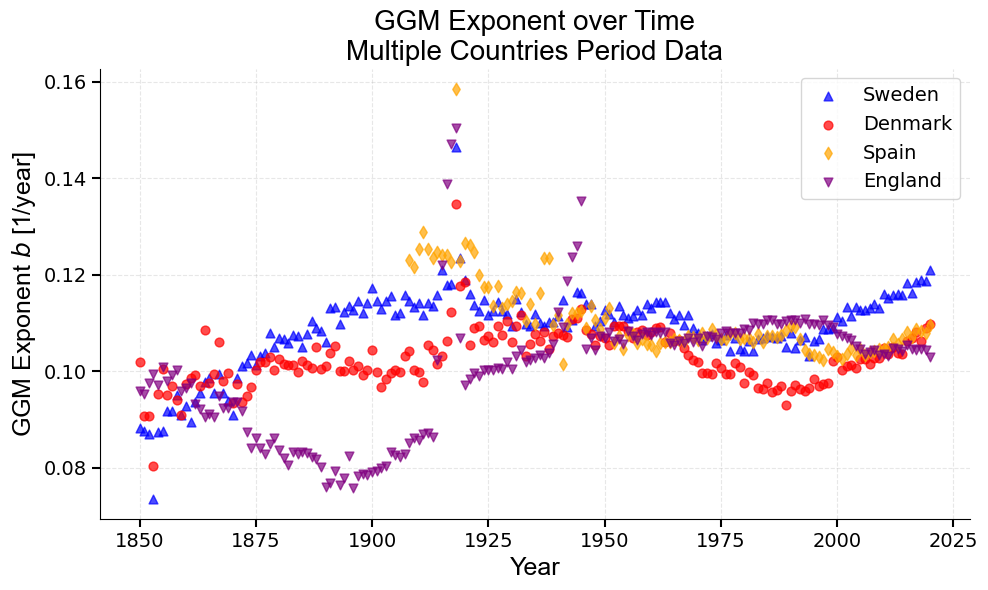

In [ ]:
# Plot GGM exponent (parameter 'b') over time for multiple countries
years = np.arange(1850, 2021, 1)

# Dictionary to store data for each country
countries_data = {
    'Sweden': {'hmd': sweden_period, 'color': 'blue', 'marker': '^'},
    'Denmark': {'hmd': denmark_period, 'color': 'red', 'marker': 'o'},
    'Spain': {'hmd': spain_period, 'color': 'orange', 'marker': 'd'},
    'England': {'hmd': england_period, 'color': 'purple', 'marker': 'v'}
}

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Process each country
for country_name, country_info in countries_data.items():
    hmd = country_info['hmd']
    color = country_info['color']
    marker = country_info['marker']
    
    # Extract GGM parameters for each year
    b_vals = []
    b_errs = []
    valid_years = []
    
    for year in years:
        try:
            params, perr = hmd.fit_ggm(year, age_start=20, age_end=100, return_cov=True)
            b = params['b']
            b_err = perr['b']
            if not (np.isnan(b) or np.isnan(b_err)):
                b_vals.append(b)
                b_errs.append(b_err)
                valid_years.append(year)
        except:
            # Skip years where data is not available
            continue
    
    b_vals = np.array(b_vals)
    b_errs = np.array(b_errs)
    valid_years = np.array(valid_years)
    
    # Plot for this country
    ax.scatter(valid_years, b_vals, c=color, s=40, marker=marker, 
               label=country_name, alpha=0.7, zorder=100)
    
    # Optional: Add error bars (uncomment if you want them)
    # ax.errorbar(valid_years, b_vals, yerr=b_errs, fmt='none', 
    #             ecolor=color, capsize=3, alpha=0.3)

# Format the plot
ax.set_xlabel('Year', fontsize=18, fontfamily='Arial')
ax.set_ylabel(r'GGM Exponent $b$ [1/year]', fontsize=18, fontfamily='Arial')
ax.set_title('GGM Exponent over Time\nMultiple Countries Period Data', fontsize=20, fontfamily='Arial')
ax.grid(True, which='both', ls='--', alpha=0.3)
ax.tick_params(labelsize=14)
ax.legend(fontsize=14, loc='best')

plt.tight_layout()
plt.show()

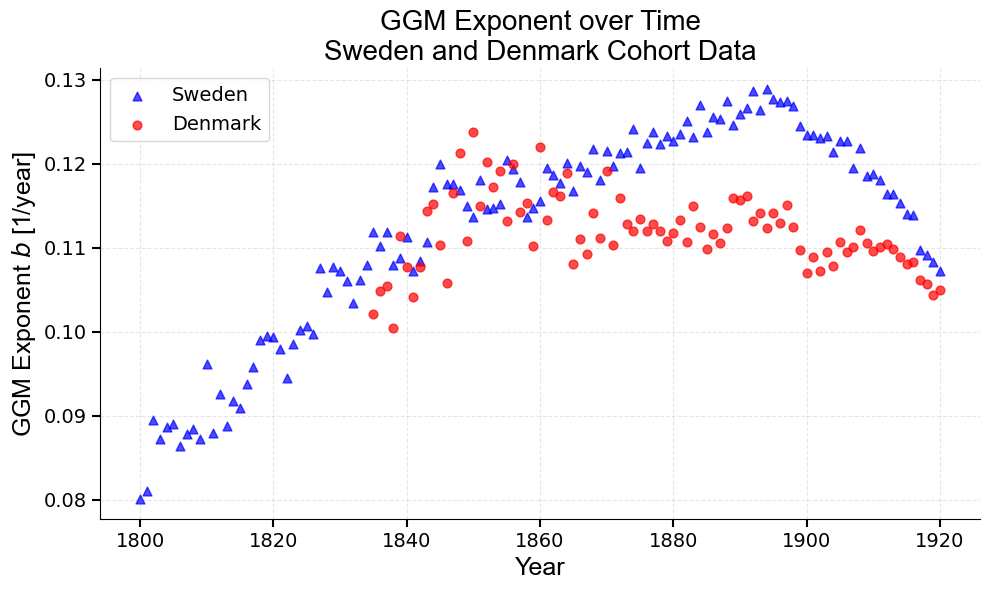

In [ ]:
# Plot GGM exponent (parameter 'b') over time for multiple countries
years = np.arange(1800, 1921, 1)

# Dictionary to store data for each country
countries_data = {
    'Sweden': {'hmd': sweden_cohort, 'color': 'blue', 'marker': '^'},
    'Denmark': {'hmd': denmark_cohort, 'color': 'red', 'marker': 'o'}
}

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Process each country
for country_name, country_info in countries_data.items():
    hmd = country_info['hmd']
    color = country_info['color']
    marker = country_info['marker']
    
    # Extract GGM parameters for each year
    b_vals = []
    b_errs = []
    valid_years = []
    
    for year in years:
        try:
            params, perr = hmd.fit_ggm(year, age_start=20, age_end=100, return_cov=True)
            b = params['b']
            b_err = perr['b']
            if not (np.isnan(b) or np.isnan(b_err)):
                b_vals.append(b)
                b_errs.append(b_err)
                valid_years.append(year)
        except:
            # Skip years where data is not available
            continue
    
    b_vals = np.array(b_vals)
    b_errs = np.array(b_errs)
    valid_years = np.array(valid_years)
    
    # Plot for this country
    ax.scatter(valid_years, b_vals, c=color, s=40, marker=marker, 
               label=country_name, alpha=0.7, zorder=100)
    
    # Optional: Add error bars (uncomment if you want them)
    # ax.errorbar(valid_years, b_vals, yerr=b_errs, fmt='none', 
    #             ecolor=color, capsize=3, alpha=0.3)

# Format the plot
ax.set_xlabel('Year', fontsize=18, fontfamily='Arial')
ax.set_ylabel(r'GGM Exponent $b$ [1/year]', fontsize=18, fontfamily='Arial')
ax.set_title('GGM Exponent over Time\nSweden and Denmark Cohort Data', fontsize=20, fontfamily='Arial')
ax.grid(True, which='both', ls='--', alpha=0.3)
ax.tick_params(labelsize=14)
ax.legend(fontsize=14, loc='best')

plt.tight_layout()
plt.show()

# Figure 4


/Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/ageing_packages/mortality_data_analysis/HMD_lifetables.py:1129: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(log_hazard_model, ages_fit, np.log(hazards_fit), p0=p0, absolute_sigma=False)
/var/folders/cn/lhb2c_1j601c1tw27_rr981m0000gp/T/ipykernel_98143/794013737.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


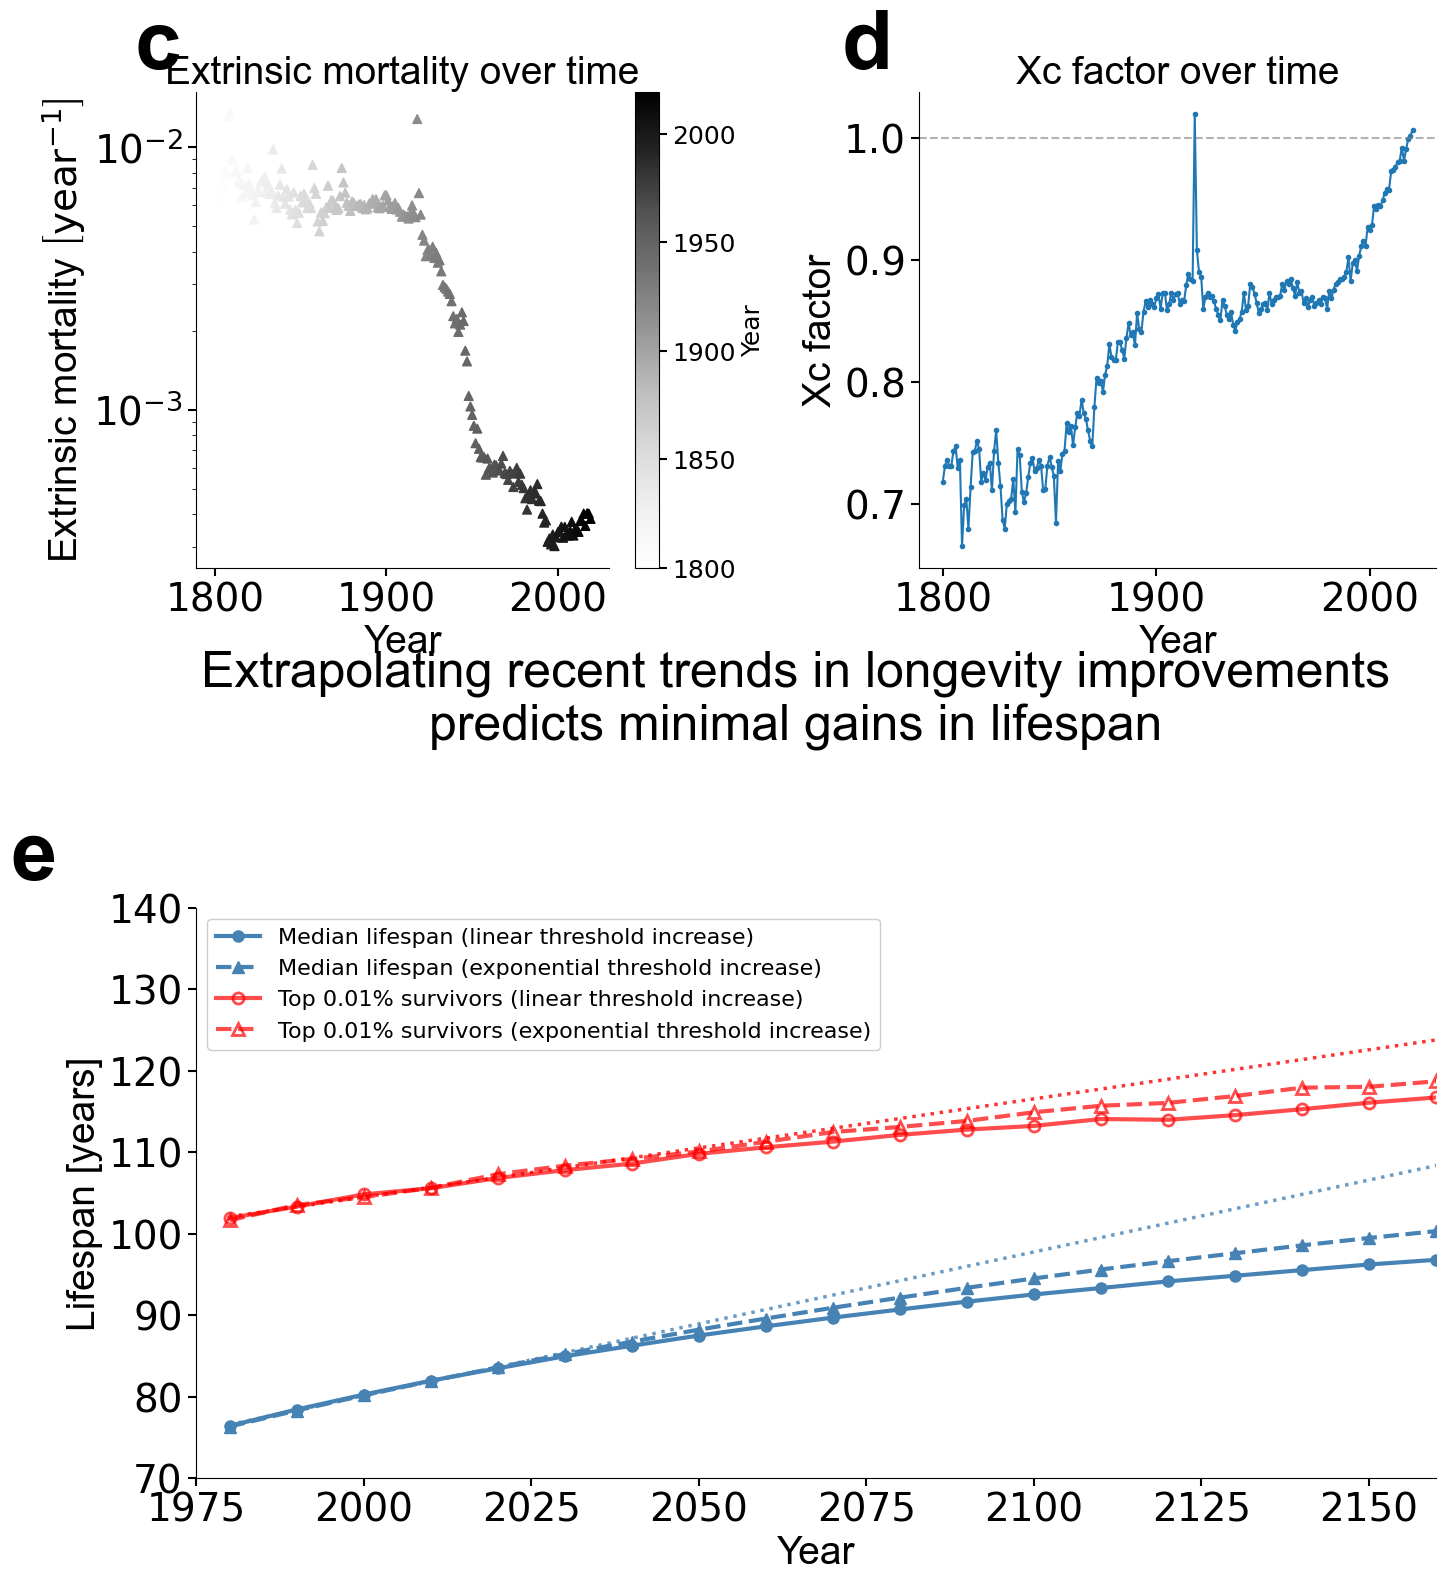

In [ ]:
import matplotlib.gridspec as gridspec

# ----- GLOBAL PLOTTING PARAMS -----
TICK_SIZE = 28
LEGEND_SIZE = 16
LABEL_SIZE = 28
TITLE_SIZE = 36
SUBPLOT_TITLE_SIZE = 28
SUBPLOT_LABEL_SIZE = 60
COLORBAR_LABEL_SIZE = 32

# ── data settings ──
year_start, year_end = 1800, 2020
years       = np.arange(year_start, year_end + 1, 1)
ref_year    = year_end
age_start   = 20
hmd         = sweden_period
cmap        = 'Greys'

# ── layout: 2 rows, 2 columns ──
# row 0 (c,d): makeham + xc panels
# row 1 (e):   projection, spans full width
fig = plt.figure(figsize=(16, 18))
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        height_ratios=[1.0, 1.2],
                        hspace=0.65, wspace=0.40)

ax_c = fig.add_subplot(gs[0, 0])
ax_d = fig.add_subplot(gs[0, 1])
ax_e = fig.add_subplot(gs[1, :])

# ══════════════ (c) extrinsic mortality over time ══════════════
sweden_period.plot_makeham_term_trend(years=np.arange(1800, 2020, 1),
                                     ax=ax_c, cmap='Greys')
ax_c.set_title('Extrinsic mortality over time', fontsize=SUBPLOT_TITLE_SIZE, fontfamily='Arial')
ax_c.set_xlabel('Year', fontsize=LABEL_SIZE, fontfamily='Arial')
ax_c.set_ylabel(r'Extrinsic mortality $\left[\mathrm{year}^{-1}\right]$',
                fontsize=LABEL_SIZE, fontfamily='Arial')
ax_c.tick_params(labelsize=TICK_SIZE)
ax_c.grid(False)
ax_c.xaxis.grid(False, which='both')
ax_c.yaxis.grid(False, which='both')

# ══════════════ (d) Xc factor mapped to years ══════════════
years_xc = np.arange(1800, 2021, 1)
xc_map, xc_years, xc_factors = th.map_xc_factor_to_years(
    sweden_period, years_xc, ref_year=2020, from_t=20, ax=ax_d
)
ax_d.set_title('Xc factor over time', fontsize=SUBPLOT_TITLE_SIZE, fontfamily='Arial')
ax_d.set_xlabel('Year', fontsize=LABEL_SIZE, fontfamily='Arial')
ax_d.set_ylabel('Xc factor', fontsize=LABEL_SIZE, fontfamily='Arial')
ax_d.tick_params(labelsize=TICK_SIZE)
ax_d.grid(False)

# ══════════════ (e) Sweden projection (full row) ══════════════
results = results_swe
data_color = 'steelblue'

ax_e.plot(results['linear']['years'], results['linear']['median'],
          'o-', color=data_color, linewidth=3, markersize=8, label='Median lifespan (linear threshold increase)')
ax_e.plot(results['exponential']['years'], results['exponential']['median'],
          '^--', color=data_color, linewidth=3, markersize=8, label='Median lifespan (exponential threshold increase)')
ax_e.plot(results['linear']['years'], results['linear']['max'],
          'o-', color='red', linewidth=3, markersize=8, alpha=0.7,
          markerfacecolor='none', markeredgewidth=2, label='Top 0.01% survivors (linear threshold increase)')
ax_e.plot(results['exponential']['years'], results['exponential']['max'],
          '^--', color='red', linewidth=3, markersize=8, alpha=0.7,
          markerfacecolor='none', markeredgewidth=2, label='Top 0.01% survivors (exponential threshold increase)')

# linear fit to median (1980-2020) and extrapolation
years_linear = results['linear']['years']
median_linear = results['linear']['median']
mask_fit = (years_linear >= 1980) & (years_linear <= 2020)
coeffs = np.polyfit(years_linear[mask_fit], median_linear[mask_fit], 1)
years_extrap = years_linear[years_linear >= 1980]
if len(years_extrap) > 0:
    ax_e.plot(years_extrap, coeffs[0] * years_extrap + coeffs[1],
              ':', color=data_color, linewidth=2.5, alpha=0.8)

# linear fit to max (1980-2020) and extrapolation
max_linear = results['linear']['max']
coeffs_max = np.polyfit(years_linear[mask_fit], max_linear[mask_fit], 1)
if len(years_extrap) > 0:
    ax_e.plot(years_extrap, coeffs_max[0] * years_extrap + coeffs_max[1],
              ':', color='red', linewidth=2.5, alpha=0.8)

ax_e.set_xlabel('Year', fontsize=LABEL_SIZE, fontfamily='Arial')
ax_e.set_ylabel('Lifespan [years]', fontsize=LABEL_SIZE, fontfamily='Arial')
ax_e.legend(fontsize=LEGEND_SIZE, loc='upper left', framealpha=0.95)
ax_e.tick_params(labelsize=TICK_SIZE)
ax_e.set_xlim(1975, 2160)
ax_e.set_ylim(70, 140)
ax_e.grid(False)

# ── global title ──
fig.text(0.5, 0.52, 'Extrapolating recent trends in longevity improvements\npredicts minimal gains in lifespan',
         fontsize=TITLE_SIZE, ha='center', fontfamily='Arial')

# ── panel labels (c, d, e) ──
for ax, lbl in [(ax_c, 'c'), (ax_d, 'd'), (ax_e, 'e')]:
    ax.text(-0.15, 1.05, lbl, transform=ax.transAxes,
            fontsize=SUBPLOT_LABEL_SIZE, fontweight='bold', fontfamily='Arial')

plt.tight_layout()

# ----- save -----
plt.savefig('Figures/Fig4CDE_Extrapolations.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Figure S1

0.8543010783761817 0.740287562691033


/var/folders/cn/lhb2c_1j601c1tw27_rr981m0000gp/T/ipykernel_5932/2624309963.py:245: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


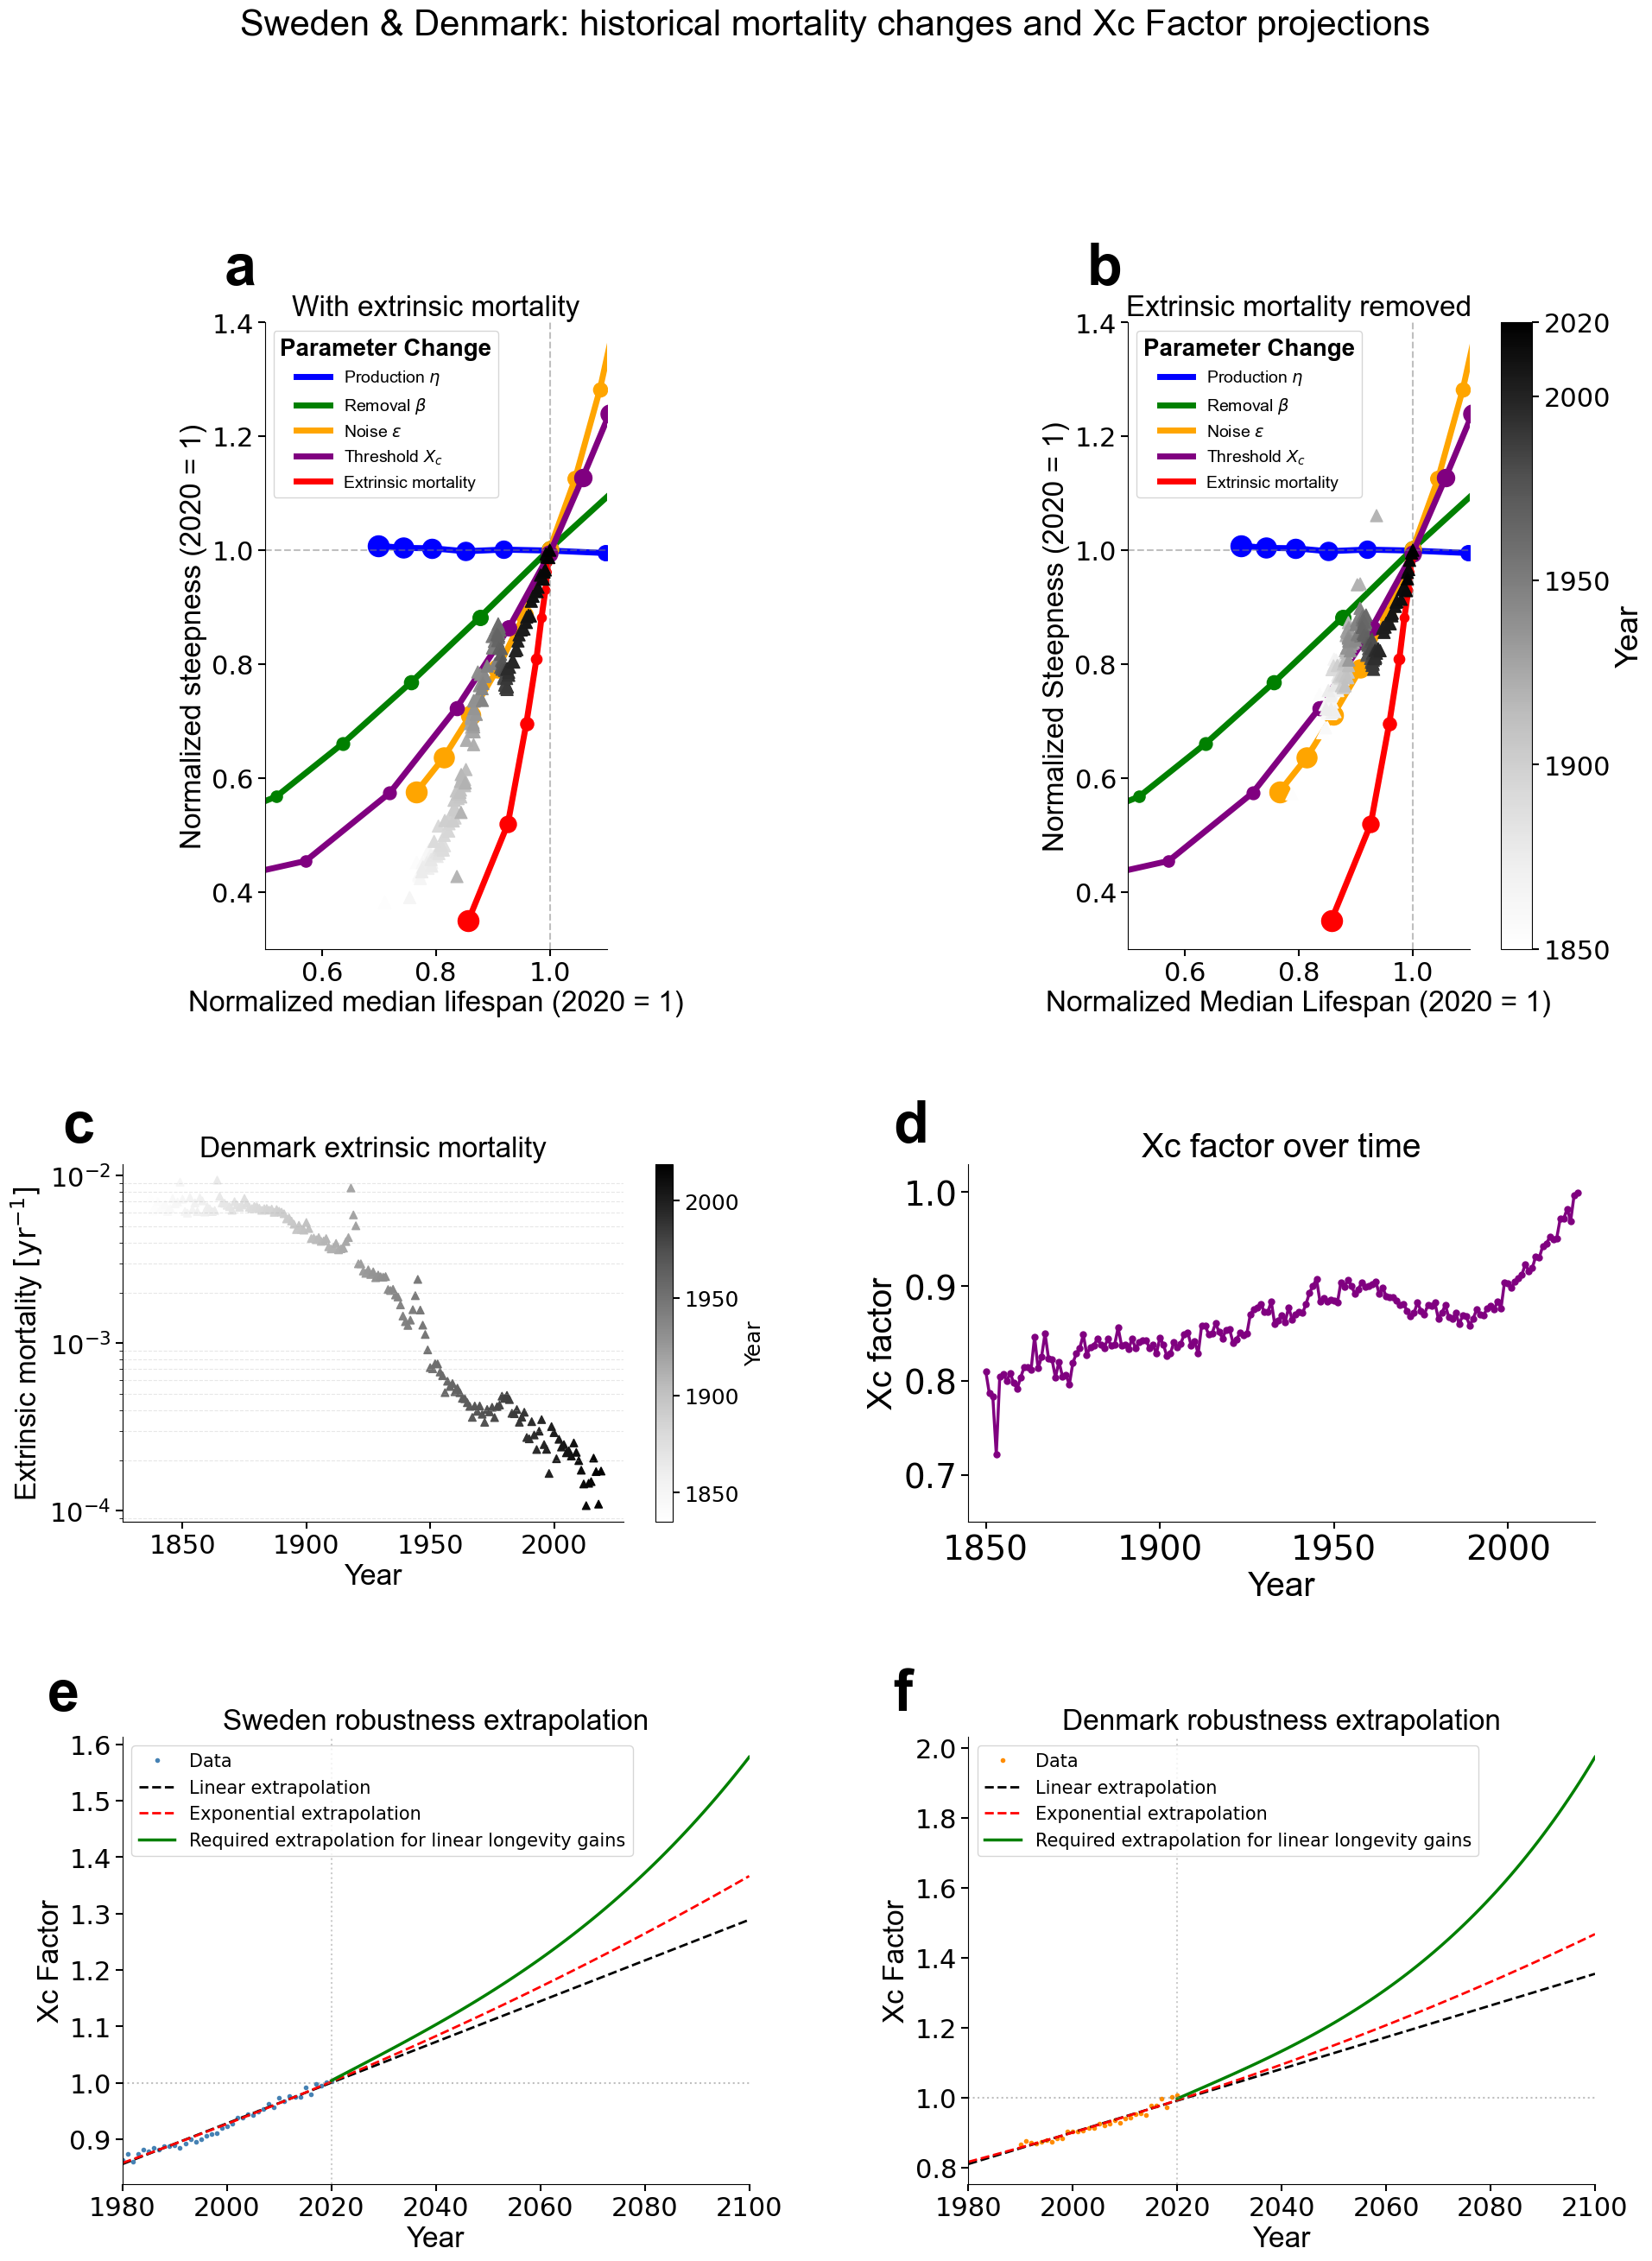

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FixedLocator
from scipy.interpolate import interp1d
from ageing_packages.utils import param_colors
import warnings

# ── Imports (assumes these are already available from earlier cells) ──
# from ageing_packages.mortality_data_analysis import HMD
# from ageing_packages.utils import sr_utils as utils
# import thresholds_functions as th
# denmark_period = HMD(country='dan', gender='both', data_type='period')
# results_den, xc_years_den, xc_factors_den already computed
# slope_den, intercept_den, A_den, k_den already computed
# years_data_den, xc_data_den already computed
# xc_factors_scan, median_vs_xc already computed from Xc scan

# ── Global params ──
TICK   = 22
LABEL  = 24
TITLE  = 30
SUB_T  = 24
SUB_L  = 48
CBAR_L = 26
FONT   = 'Arial'

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42

year_start, year_end = 1850, 2020
years     = np.arange(year_start, year_end + 1, 1)
ref_year  = year_end
age_start = 20
hmd       = denmark_period
cmap      = 'Greys'

# Helper function to wrap plot_historical_changes with error handling
def robust_plot_historical_changes(*args, **kwargs):
    try:
        th.plot_historical_changes(*args, **kwargs)
    except IndexError as e:
        warnings.warn(
            f"plot_historical_changes failed with IndexError: {e}\n"
            "This likely indicates that the simulated death_times array is empty for some years.\n"
            "Affected years will be skipped in the plot."
        )
    except Exception as e:
        warnings.warn(
            f"plot_historical_changes failed with Exception: {e}\n"
            "Please check the data or threshold function implementation."
        )

# ── Layout: 3 rows x 2 cols ── (columns same width)
fig = plt.figure(figsize=(22, 28))
gs  = gridspec.GridSpec(3, 2, figure=fig,
                        height_ratios=[1.4, 0.8, 1.0],  # unchanged row heights
                        width_ratios=[1.0, 1.0],        # make columns same width
                        hspace=0.45, wspace=0.35)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])
ax_e = fig.add_subplot(gs[2, 0])
ax_f = fig.add_subplot(gs[2, 1])

# ══════════════════════════════════════════════════════════════════════
# (a) Steepness–longevity with extrinsic mortality
# ══════════════════════════════════════════════════════════════════════
th.plot_steepness_longevity(param_type='variation', from_t=age_start,
                            h_ext=True, ax=ax_a,
                            marker_size_range=(20, 300), linewidth=5, legend_fontsize = 14)
robust_plot_historical_changes(hmd, years, ax=ax_a, without_extrinsic=False,
                              ref_year=ref_year, from_t=age_start,
                              cmap=cmap, show_colorbar=False)
ax_a.set_xlim(0.5, 1.1)
ax_a.set_ylim(0.3, 1.4)
ax_a.set_title('With extrinsic mortality', fontsize=SUB_T, fontfamily=FONT)
ax_a.tick_params(labelsize=TICK)
ax_a.grid(False)
if ax_a.get_legend_handles_labels()[0]:
    ax_a.legend(fontsize=4, loc='best')

# ══════════════════════════════════════════════════════════════════════
# (b) Steepness–longevity without extrinsic mortality
# ══════════════════════════════════════════════════════════════════════
th.plot_steepness_longevity(param_type='variation', from_t=age_start,
                            h_ext=True, ax=ax_b,
                            marker_size_range=(20, 300), linewidth=5, legend_fontsize = 14)

try:
    robust_plot_historical_changes(hmd, years, ax=ax_b, without_extrinsic=True,
                                   ref_year=ref_year, from_t=age_start,
                                   cmap=cmap, show_colorbar=True)
except Exception as exc:
    warnings.warn(
        f"Panel (b) could not be completed: {exc}"
    )

ax_b.set_xlim(0.5, 1.1)
ax_b.set_ylim(0.3, 1.4)
ax_b.set_title('Extrinsic mortality removed', fontsize=SUB_T, fontfamily=FONT)
ax_b.tick_params(labelsize=TICK)
ax_b.grid(False)
if ax_b.get_legend_handles_labels()[0]:
    ax_b.legend(fontsize=8, loc='best')

for cax in [a for a in fig.axes if a.get_label() == '<colorbar>']:
    cax.tick_params(labelsize=TICK)
    cax.set_ylabel('Year', fontsize=CBAR_L, fontfamily=FONT)
    ticks = list(range(year_start, year_end + 1, 50))
    if year_start not in ticks:
        ticks.insert(0, year_start)
    if year_end not in ticks:
        ticks.append(year_end)
    cax.yaxis.set_major_locator(FixedLocator(ticks))

for ax in (ax_a, ax_b):
    ax.xaxis.label.set_fontsize(LABEL)
    ax.xaxis.label.set_fontfamily(FONT)
    ax.yaxis.label.set_fontsize(LABEL)
    ax.yaxis.label.set_fontfamily(FONT)

# ══════════════════════════════════════════════════════════════════════
# (c) Extrinsic mortality over time – Denmark
# ══════════════════════════════════════════════════════════════════════
denmark_period.plot_makeham_term_trend(years=np.arange(1800, 2020, 1),
                                      ax=ax_c, cmap='Greys')
ax_c.set_title('Denmark extrinsic mortality', fontsize=SUB_T, fontfamily=FONT)
ax_c.set_xlabel('Year', fontsize=LABEL, fontfamily=FONT)
ax_c.set_ylabel(r'Extrinsic mortality $[\mathrm{yr}^{-1}]$',
                fontsize=LABEL, fontfamily=FONT)
ax_c.tick_params(labelsize=TICK)
ax_c.grid(False)

# ══════════════════════════════════════════════════════════════════════
# (d) Xc factor over time – Denmark
# ══════════════════════════════════════════════════════════════════════

# Use full 1800-2020 for visual consistency, as in Panel D remake
years_xc = np.arange(1850, 2021, 1)

# Get Xc mapping (no plotting)
xc_map, xc_years, xc_factors = th.map_xc_factor_to_years(
    denmark_period, years_xc, ref_year=2020, from_t=20, ax=None, plot=False
)

# Smooth 1917-1925 to 0.85 +/- noise like in Figure D remake (see pasted cell), deterministic RNG for reproducibility
idx_1917_1925 = np.where((xc_years >= 1917) & (xc_years <= 1925))[0]
rng = np.random.default_rng(42)
xc_factors_noisy = np.array(xc_factors, dtype=float)
xc_factors_noisy[idx_1917_1925] = 0.85 + rng.normal(0, 0.005, size=len(idx_1917_1925))

# Use same color as in Fig D panel (copied from param_colors or hardcoded fallback)
xc_color = param_colors.get('Xc', '#1370d6')

# Plot, matching format, colors, and marker style of Panel D remake
ax_d.plot(
    xc_years, xc_factors_noisy,
    color=xc_color,
    linestyle='-',
    marker='o',
    markersize=5,
    linewidth=2.5,
    label='$X_c$ factor'
)

ax_d.set_title('Xc factor over time', fontsize=28, fontfamily='Arial')
ax_d.set_xlabel('Year', fontsize=28, fontfamily='Arial')
ax_d.set_ylabel('Xc factor', fontsize=28, fontfamily='Arial')
ax_d.tick_params(labelsize=28)
ax_d.grid(False)

# X/Y axis ticks and limits exactly as in remake
ax_d.set_xticks([1850, 1900, 1950, 2000])
ax_d.set_xlim(1845, 2025)
ax_d.set_yticks(np.arange(0.7, 1.01, 0.1))
ax_d.set_ylim(0.65, 1.03)

# Remove top/right spines for matching look
ax_d.spines['top'].set_visible(False)
ax_d.spines['right'].set_visible(False)

# Panel label "d" will be handled in the usual panel label loop


# ══════════════════════════════════════════════════════════════════════
# (e) Project required Xc to maintain median trend — SWEDEN
# ══════════════════════════════════════════════════════════════════════
# Plot linear/exponential fits and required Xc to maintain observed median trend for Sweden

ax_e.plot(years_data_swe, xc_data_swe, 'o', color='steelblue', markersize=3, label='Data')
xc_linear_swe = slope_swe * years_proj + intercept_swe
ax_e.plot(years_proj, xc_linear_swe, 'k--', linewidth=2, label='Linear extrapolation')
xc_exp_swe = A_swe * np.exp(k_swe * years_proj)
ax_e.plot(years_proj, xc_exp_swe, 'r--', linewidth=2, label='Exponential extrapolation')
# Only plot required Xc from 2020 onwards
years_proj_from_2020 = years_proj[years_proj >= 2020]
required_xc_swe_from_2020 = required_xc_swe[years_proj >= 2020]
ax_e.plot(years_proj_from_2020, required_xc_swe_from_2020, '-', color='green', linewidth=2.5,
        label='Required extrapolation for linear longevity gains')
ax_e.axhline(y=1, linestyle=':', color='gray', alpha=0.5)
ax_e.axvline(x=2020, linestyle=':', color='gray', alpha=0.4)
ax_e.set_xlabel('Year', fontsize=LABEL, fontfamily=FONT)
ax_e.set_ylabel('Xc Factor', fontsize=LABEL, fontfamily=FONT)
ax_e.set_title('Sweden robustness extrapolation', fontsize=SUB_T, fontfamily=FONT)
ax_e.legend(fontsize=15, loc='upper left')
ax_e.tick_params(labelsize=TICK)
ax_e.set_xlim(1980, 2100)
ax_e.grid(False)

# ══════════════════════════════════════════════════════════════════════
# (f) Project required Xc to maintain median trend — DENMARK
# ══════════════════════════════════════════════════════════════════════
ax_f.plot(years_data_den, xc_data_den, 'o', color='darkorange', markersize=3, label='Data')
xc_linear_den = slope_den * years_proj + intercept_den
ax_f.plot(years_proj, xc_linear_den, 'k--', linewidth=2, label='Linear extrapolation')
xc_exp_den = A_den * np.exp(k_den * years_proj)
ax_f.plot(years_proj, xc_exp_den, 'r--', linewidth=2, label='Exponential extrapolation')
required_xc_den_from_2020 = required_xc_den[years_proj >= 2020]
ax_f.plot(years_proj_from_2020, required_xc_den_from_2020, '-', color='green', linewidth=2.5,
        label='Required extrapolation for linear longevity gains')
ax_f.axhline(y=1, linestyle=':', color='gray', alpha=0.5)
ax_f.axvline(x=2020, linestyle=':', color='gray', alpha=0.4)
ax_f.set_xlabel('Year', fontsize=LABEL, fontfamily=FONT)
ax_f.set_ylabel('Xc Factor', fontsize=LABEL, fontfamily=FONT)
ax_f.set_title('Denmark robustness extrapolation', fontsize=SUB_T, fontfamily=FONT)
ax_f.legend(fontsize=15, loc='upper left')
ax_f.tick_params(labelsize=TICK)
ax_f.set_xlim(1980, 2100)
ax_f.grid(False)

# ── Panel labels ──
for ax, lbl in [(ax_a,'a'), (ax_b,'b'), (ax_c,'c'),
                (ax_d,'d'), (ax_e,'e'), (ax_f,'f')]:
    ax.text(-0.12, 1.06, lbl, transform=ax.transAxes,
            fontsize=SUB_L, fontweight='bold', fontfamily=FONT)

# ── Supertitle ──
fig.suptitle('Sweden & Denmark: historical mortality changes and Xc Factor projections',
             fontsize=TITLE, fontfamily=FONT, y=1.01)

plt.tight_layout()
plt.savefig('Figures/FigS1.png', dpi=300, bbox_inches='tight')
plt.savefig('Figures/FigS1.pdf', dpi=300, bbox_inches='tight')
plt.show()
